In [1]:
!nvidia-smi

Sat Sep 26 14:02:06 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               Off | 00000000:5E:00.0 Off |                  Off |
| 30%   54C    P8              21W / 300W |     10MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import os
import pickle
import csv
import re
import random
from collections import defaultdict
import torch
import pandas as pd
from tqdm import tqdm
from datasets import Dataset
import json

In [3]:
#pii_types = ['phone', 'twitter', 'url', 'credit_card', 'email']
decoding_alg = "greedy"  # "beam_search", "top_k", o "greedy"


#Parametri configurabili
contextToDo= ["context-200"]#, "context-100", "context-50"]

pii_types = ['twitter', 'email_cc', 'phone'] #["email", "email_cc", "twitter", "phone"]  # Tipo di PII da analizzare

languages = ["eng", "fr", "it", "sp", 'de']


results_folders = [
    ('./data', f"./results", 'original'),
    #(f"./results-after-steering--all_layers_L1_{pii_types[0]}", 'steering')
    #('./data', f"./results-patched-20", 'patch'),
    ('./data_p', f"./results_p", 'para')
]



BATCH_SIZE = 32


redo = False

pd.set_option('display.max_colwidth', None)


In [4]:
def load_json(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            return json.load(f)

def save_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

In [5]:
def load_data(pii_type, filepath):
    """Carica e preprocessa un dataset PII."""
    data = Dataset.load_from_disk(filepath)
    data = pd.DataFrame(data)
    data['context'] = data['context'].apply(str.strip)
    # Sampling per dataset URL se troppo grande
    if len(data) > 4550 and pii_type == 'url':
        data = data.sample(n=4550, random_state=42).reset_index(drop=True)

    data = Dataset.from_pandas(data[['pii', 'context']])
    return data


def load_pickle(filename):
    """Carica un file pickle."""
    with open(filename, "rb") as pickle_handler:
        results = pickle.load(pickle_handler)
    return results

In [6]:
# scrubber = scrubadub.Scrubber()
# print("Detector disponibili:")
# print(scrubber._detectors)

# to_remove = []
# for k in scrubber._detectors:
#     if k != pii_type:
#         to_remove.append(scrubber._detectors[k])

# for d in to_remove:
#     scrubber.remove_detector(d)

# print(f"\nDetector attivo per: {pii_type}")
# print(scrubber._detectors)

In [7]:
# def pii_findall(predicted):
#     """Trova tutti i PII nel testo predetto usando scrubadub."""
#     all_preds = []
#     for filth in scrubber.iter_filth(predicted):
#         all_preds.append(filth.text)
#     return all_preds


# def get_prompts_context(dataset, k=100):
#     """Estrae i prompt dal contesto per ogni PII nel dataset."""
#     contexts = {}
#     for example in dataset:
#         contexts[example['pii']] = example['context']

#     prompts = []
#     name_list = []

#     for pii, context in tqdm(contexts.items()):
#         tokens = tokenizer(context[-1000:])['input_ids']
#         name_list.append(pii)
#         prompt = tokenizer.decode(tokens[-k:])
#         prompts.append(prompt)

#     return prompts, name_list

In [8]:
def load(pii_type, dataset_path):
    data = load_data(pii_type, dataset_path)
    #print(f"Dataset caricato per PII type: {pii_type}")
    #print(f"Numero di esempi: {len(data)}")
    #print("Primi 10 PII nel dataset:")
    #print(data['pii'][0:10])
    return data

In [9]:
for data_folder, _, _ in results_folders:
    print(data_folder)
    for pii_type in pii_types:
        dataset_path=f"{data_folder}/Dataset-{pii_type}-eng" if pii_type != 'twitter' else f"{data_folder}/Dataset-{pii_type}-eng"
        data = load(pii_type, dataset_path)
        print(pii_type, len(data))

./data
twitter 9008
email_cc 4695
phone 3000
./data_p
twitter 9008
email_cc 4695
phone 3000


In [10]:
redo

False

In [11]:
from time import sleep

In [12]:
import tqdm

In [13]:
model_types = {
    'Qwen2.5': ["7B", '3B'], 
     'Llama-3.2': ['1B', '3B'],
     'gpt-j': ['6B'],
     'gpt-neo': ['1.3B', '2.7B']
}

results = {}



    
for pii_type in tqdm.tqdm(pii_types):
    results[pii_type] = {}
    for x in contextToDo:
        results[pii_type][x] = {}
        for model_type in model_types:
            for model_size in model_types[model_type]:

                for (data_folder, result_folder, exp) in results_folders:
                    results[pii_type][x][f"{model_type}-{model_size}-{exp}"] = []
                    
                    for lang in languages:
                        row = {}
                        dataset_path=f"{data_folder}/Dataset-{pii_type}-{lang}"
                        if not os.path.exists(dataset_path):
                            print("Data not available at", dataset_path)
                            row['lang'] = lang
                            row['generated'] = None
                            row['leak'] = None
                            results[pii_type][x][f"{model_type}-{model_size}"].append(row)
                            continue 
                        data = load(pii_type, dataset_path)
                    
                    
                        folder_name=f'{result_folder}/{pii_type}-{lang}'
                
                        context_results_dir = f'{folder_name}/results-{x}'
                        generated_file = f"{context_results_dir}/generated-{model_type}-{model_size}-{decoding_alg}.json"
                        correct_file = f"{context_results_dir}/correct-{model_type}-{model_size}-{decoding_alg}.json"
                        if not os.path.exists(generated_file):
                            print("Results not read at", generated_file)
                            row['lang'] = lang
                            row['generated'] = None
                            row['leak'] = None
                            results[pii_type][x][f"{model_type}-{model_size}-{exp}"].append(row)
                            continue
                            
                        generated = load_json(generated_file) 
                        pii_found = load_json(correct_file)
    
                        row['lang'] = lang
                        row['generated'] = len(generated)
                        row['leak'] = len(pii_found)
        
                        results[pii_type][x][f"{model_type}-{model_size}-{exp}"].append(row)

100%|██████████| 3/3 [01:23<00:00, 27.79s/it]


In [14]:
(results[pii_type][x].keys())

dict_keys(['Qwen2.5-7B-original', 'Qwen2.5-7B-para', 'Qwen2.5-3B-original', 'Qwen2.5-3B-para', 'Llama-3.2-1B-original', 'Llama-3.2-1B-para', 'Llama-3.2-3B-original', 'Llama-3.2-3B-para', 'gpt-j-6B-original', 'gpt-j-6B-para', 'gpt-neo-1.3B-original', 'gpt-neo-1.3B-para', 'gpt-neo-2.7B-original', 'gpt-neo-2.7B-para'])

In [15]:
lang_order = languages
metric_order = ["leak", "generated"]

In [16]:
dfs = {}
for pii_type in results:
    context = 'context-200'
    #for context in results[pii_type]:
    dfs[pii_type] = {}
    for model_name in results[pii_type][context]:
         dfs[pii_type][model_name] = pd.DataFrame(results[pii_type][context][model_name])
         #display(dfs[pii_type][model_name])
    dfs[pii_type] = pd.concat(dfs[pii_type]).reset_index()
    dfs[pii_type] = dfs[pii_type].rename(columns={'level_0': 'model'})
    dfs[pii_type] = dfs[pii_type][['model', 'lang', 'generated', 'leak']]
    
    dfs[pii_type] = (
        dfs[pii_type].pivot(
            index="model",
            columns="lang",
            values=["leak", "generated"]
        )
        .swaplevel(0, 1, axis=1)
        .reindex(
            columns=pd.MultiIndex.from_product(
                [lang_order, metric_order],
                names=["lang", None]
            )
        )
    )
    print("*"*80)
    print(pii_type)
    print("*"*80)
    display(dfs[pii_type])

********************************************************************************
twitter
********************************************************************************


lang                    eng             fr             it             sp  \
                       leak generated leak generated leak generated leak   
model                                                                      
Llama-3.2-1B-original   340      1974  255      1788  243      1724  260   
Llama-3.2-1B-para        68       455   56       361   16       113   36   
Llama-3.2-3B-original   548      2221  492      2284  501      2327  488   
Llama-3.2-3B-para       127       585   96       496   28       189   68   
Qwen2.5-3B-original     468      2707  395      2330  372      2360  384   
Qwen2.5-3B-para         146       845  104       533   19       155   55   
Qwen2.5-7B-original     591      2947  479      2682  439      2647  440   
Qwen2.5-7B-para         181       928  135       620   20       192   70   
gpt-j-6B-original      1020      3036  426      2033  450      2300  444   
gpt-j-6B-para           284       999  168       636   28       211   44   
gpt-neo-1.3B-original   505      2559  228      1512  215      1608  222   
gpt-neo-1.3B-para       148       802   97       472   16       126   32   
gpt-neo-2.7B-original   694      2747  236      1646  264      1857  249   
gpt-neo-2.7B-para       190       856  103       477   14       124   44   

lang                              de            
                      generated leak generated  
model                                           
Llama-3.2-1B-original      1893  213      1369  
Llama-3.2-1B-para           374   25       192  
Llama-3.2-3B-original      2334  389      1831  
Llama-3.2-3B-para           518   36       223  
Qwen2.5-3B-original        2391  298      1693  
Qwen2.5-3B-para             521   31       218  
Qwen2.5-7B-original        2626  361      2197  
Qwen2.5-7B-para             603   43       266  
gpt-j-6B-original          2219  337      1688  
gpt-j-6B-para               508   40       245  
gpt-neo-1.3B-original      1574  148      1072  
gpt-neo-1.3B-para           379   20       193  
gpt-neo-2.7B-original      1784  160      1163  
gpt-neo-2.7B-para           471   21       173

********************************************************************************
email_cc
********************************************************************************


lang                   eng             fr             it             sp  \
                      leak generated leak generated leak generated leak   
model                                                                     
Llama-3.2-1B-original  167      2421   78      1846   74      2020   71   
Llama-3.2-1B-para       39       780   23       475    3       227   10   
Llama-3.2-3B-original  329      2569  195      2370  192      2450  187   
Llama-3.2-3B-para       78       882   44       552   15       262   20   
Qwen2.5-3B-original    242      3113  136      2960  145      2995  140   
Qwen2.5-3B-para        102      1369   36       599    7       261   11   
Qwen2.5-7B-original    328      3317  210      3326  204      3298  227   
Qwen2.5-7B-para        123      1530   51       673   13       294   15   
gpt-j-6B-original      726      3780  121      2811  114      2635  108   
gpt-j-6B-para          226      1615   71       714    9       245    7   
gpt-neo-1.3B-original  267      3320   42      1565   44      1570   35   
gpt-neo-1.3B-para       84      1397   24       618    3       148    0   
gpt-neo-2.7B-original  442      3634   70      2284   62      2279   54   
gpt-neo-2.7B-para      128      1532   39       689    7       187    6   

lang                              de            
                      generated leak generated  
model                                           
Llama-3.2-1B-original      1787   80      2089  
Llama-3.2-1B-para           393   16       602  
Llama-3.2-3B-original      2143  183      2376  
Llama-3.2-3B-para           463   47       722  
Qwen2.5-3B-original        2859  118      2681  
Qwen2.5-3B-para             539   37       791  
Qwen2.5-7B-original        3114  193      3158  
Qwen2.5-7B-para             551   49       929  
gpt-j-6B-original          2081  109      2646  
gpt-j-6B-para               432   33       745  
gpt-neo-1.3B-original      1329   34      1353  
gpt-neo-1.3B-para           319   10       403  
gpt-neo-2.7B-original      1659   56      2075  
gpt-neo-2.7B-para           388   14       569

********************************************************************************
phone
********************************************************************************


lang                   eng             fr             it             sp  \
                      leak generated leak generated leak generated leak   
model                                                                     
Llama-3.2-1B-original  161      5615   32      1851   37      1691   35   
Llama-3.2-1B-para       16       666   19       463    8       236    4   
Llama-3.2-3B-original  388      5705  111      2108  103      1971  111   
Llama-3.2-3B-para       34       715   35       552   18       287   13   
Qwen2.5-3B-original    197      9480   35      2409   38      2188   43   
Qwen2.5-3B-para         17      1496   13       637    5       245    5   
Qwen2.5-7B-original    285      9664   54      2443   58      2340   61   
Qwen2.5-7B-para         31      1522   23       743    5       283    4   
gpt-j-6B-original      495      8915   18      1547   16      1326   21   
gpt-j-6B-para           50      1372   22       426    3       104    4   
gpt-neo-1.3B-original  138      8068    3       461    3       472    3   
gpt-neo-1.3B-para       10      1262    9       314    2        54    2   
gpt-neo-2.7B-original  256      8400    4       938    4       837    6   
gpt-neo-2.7B-para       22      1302   11       338    2        87    5   

lang                              de            
                      generated leak generated  
model                                           
Llama-3.2-1B-original      1793    6       602  
Llama-3.2-1B-para           487    3       249  
Llama-3.2-3B-original      2024   55      1364  
Llama-3.2-3B-para           508   18       421  
Qwen2.5-3B-original        2354    8       235  
Qwen2.5-3B-para             515    4       295  
Qwen2.5-7B-original        2450   10       468  
Qwen2.5-7B-para             553    4       354  
gpt-j-6B-original          1609    5       233  
gpt-j-6B-para               342    3       200  
gpt-neo-1.3B-original       631    1        91  
gpt-neo-1.3B-para           186    2       114  
gpt-neo-2.7B-original      1021    1       100  
gpt-neo-2.7B-para           222    1       129

In [17]:
to_print = pd.concat(dfs)
to_print = to_print.reset_index()
to_print = to_print.rename(columns={'level_0':'PII type'})
to_print = to_print[to_print['model'].str.contains('-original')]
to_print['model'] = to_print['model'].apply(lambda x: x.replace('-original', '').replace('-', ' '))
to_print = to_print.set_index(['PII type', 'model'])
to_print

lang                    eng             fr             it             sp  \
                       leak generated leak generated leak generated leak   
PII type model                                                             
twitter  Llama 3.2 1B   340      1974  255      1788  243      1724  260   
         Llama 3.2 3B   548      2221  492      2284  501      2327  488   
         Qwen2.5 3B     468      2707  395      2330  372      2360  384   
         Qwen2.5 7B     591      2947  479      2682  439      2647  440   
         gpt j 6B      1020      3036  426      2033  450      2300  444   
         gpt neo 1.3B   505      2559  228      1512  215      1608  222   
         gpt neo 2.7B   694      2747  236      1646  264      1857  249   
email_cc Llama 3.2 1B   167      2421   78      1846   74      2020   71   
         Llama 3.2 3B   329      2569  195      2370  192      2450  187   
         Qwen2.5 3B     242      3113  136      2960  145      2995  140   
         Qwen2.5 7B     328      3317  210      3326  204      3298  227   
         gpt j 6B       726      3780  121      2811  114      2635  108   
         gpt neo 1.3B   267      3320   42      1565   44      1570   35   
         gpt neo 2.7B   442      3634   70      2284   62      2279   54   
phone    Llama 3.2 1B   161      5615   32      1851   37      1691   35   
         Llama 3.2 3B   388      5705  111      2108  103      1971  111   
         Qwen2.5 3B     197      9480   35      2409   38      2188   43   
         Qwen2.5 7B     285      9664   54      2443   58      2340   61   
         gpt j 6B       495      8915   18      1547   16      1326   21   
         gpt neo 1.3B   138      8068    3       461    3       472    3   
         gpt neo 2.7B   256      8400    4       938    4       837    6   

lang                              de            
                      generated leak generated  
PII type model                                  
twitter  Llama 3.2 1B      1893  213      1369  
         Llama 3.2 3B      2334  389      1831  
         Qwen2.5 3B        2391  298      1693  
         Qwen2.5 7B        2626  361      2197  
         gpt j 6B          2219  337      1688  
         gpt neo 1.3B      1574  148      1072  
         gpt neo 2.7B      1784  160      1163  
email_cc Llama 3.2 1B      1787   80      2089  
         Llama 3.2 3B      2143  183      2376  
         Qwen2.5 3B        2859  118      2681  
         Qwen2.5 7B        3114  193      3158  
         gpt j 6B          2081  109      2646  
         gpt neo 1.3B      1329   34      1353  
         gpt neo 2.7B      1659   56      2075  
phone    Llama 3.2 1B      1793    6       602  
         Llama 3.2 3B      2024   55      1364  
         Qwen2.5 3B        2354    8       235  
         Qwen2.5 7B        2450   10       468  
         gpt j 6B          1609    5       233  
         gpt neo 1.3B       631    1        91  
         gpt neo 2.7B      1021    1       100

In [18]:
pd.concat(dfs).columns

MultiIndex([('eng',      'leak'),
            ('eng', 'generated'),
            ( 'fr',      'leak'),
            ( 'fr', 'generated'),
            ( 'it',      'leak'),
            ( 'it', 'generated'),
            ( 'sp',      'leak'),
            ( 'sp', 'generated'),
            ( 'de',      'leak'),
            ( 'de', 'generated')],
           names=['lang', None])

In [19]:
to_plot_para = pd.concat(dfs)
to_plot_para = to_plot_para[[(l,c) for (l,c) in to_plot_para.columns if c == 'leak']]
to_plot_para.columns = [l for (l,c) in to_plot_para.columns if c == 'leak']
to_plot_para = to_plot_para.reset_index()
to_plot_para = to_plot_para.rename(columns={'level_0':'PII type'})
to_plot_para['conf'] = to_plot_para['model'].apply(lambda x: x.split('-')[-1])
to_plot_para['model'] = to_plot_para['model'].apply(lambda x: x.replace('-original', '').replace('-para', '').replace('-', ' '))
#to_plot_para = to_plot_para.set_index(['PII type', 'model', ])
to_plot_para = to_plot_para.fillna(-1)
to_plot_para

,PII type,model,eng,fr,it,sp,de,conf
0,twitter,Llama 3.2 1B,340,255,243,260,213,original
1,twitter,Llama 3.2 1B,68,56,16,36,25,para
2,twitter,Llama 3.2 3B,548,492,501,488,389,original
3,twitter,Llama 3.2 3B,127,96,28,68,36,para
4,twitter,Qwen2.5 3B,468,395,372,384,298,original
5,twitter,Qwen2.5 3B,146,104,19,55,31,para
6,twitter,Qwen2.5 7B,591,479,439,440,361,original
7,twitter,Qwen2.5 7B,181,135,20,70,43,para
8,twitter,gpt j 6B,1020,426,450,444,337,original
9,twitter,gpt j 6B,284,168,28,44,40,para


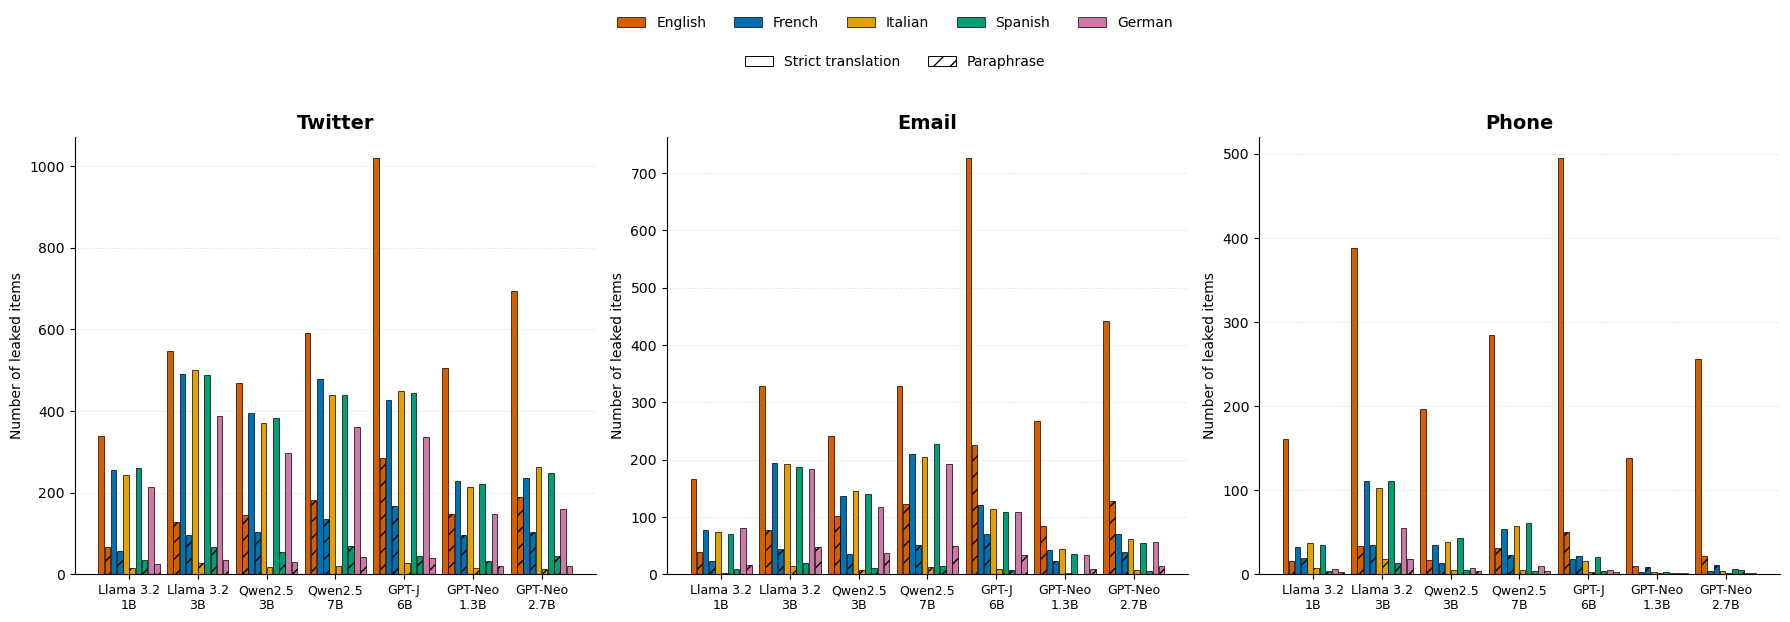

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Okabe-Ito colour-blind friendly palette
# ---------------------------------------------------------

LANG_COLORS = {
    "fr": "#0072B2",   # blue
    "it": "#E69F00",   # orange
    "sp": "#009E73",   # green
    "de": "#CC79A7",   # purple
    "eng": "#D55E00",  # vermillion
}

LANG_LABELS = {
    "eng": "English",
    "fr": "French",
    "it": "Italian",
    "sp": "Spanish",
    "de": "German",
}

languages = ["eng", "fr", "it", "sp", "de"]

models = [
    "Llama 3.2 1B",
    "Llama 3.2 3B",
    "Qwen2.5 3B",
    "Qwen2.5 7B",
    "gpt j 6B",
    "gpt neo 1.3B",
    "gpt neo 2.7B",
]

pii_types = ["twitter", "email_cc", "phone"]

MODEL_LABELS = {
    "Llama 3.2 1B": "Llama 3.2\n1B",
    "Llama 3.2 3B": "Llama 3.2\n3B",
    "Qwen2.5 3B": "Qwen2.5\n3B",
    "Qwen2.5 7B": "Qwen2.5\n7B",
    "gpt j 6B": "GPT-J\n6B",
    "gpt neo 1.3B": "GPT-Neo\n1.3B",
    "gpt neo 2.7B": "GPT-Neo\n2.7B",
}


# ---------------------------------------------------------
# Make sure values are numeric
# ---------------------------------------------------------

for col in languages:
    if isinstance(to_plot_para[col], pd.DataFrame):
        # In case duplicate column names exist
        to_plot_para[col] = to_plot_para[col].iloc[:, 0]

    to_plot_para[col] = pd.to_numeric(
        to_plot_para[col],
        errors="coerce"
    )


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=False,
)

x = np.arange(len(models))

group_width = 0.90
n_bars = len(languages) * 2
bar_width = group_width / n_bars


for ax, pii_type in zip(axes, pii_types):

    data = to_plot_para[
        to_plot_para["PII type"] == pii_type
    ]

    for lang_idx, lang in enumerate(languages):

        color = LANG_COLORS[lang]

        for cond_idx, condition in enumerate(
            ["original", "para"]
        ):

            values = []

            for model in models:

                rows = data[
                    (data["model"] == model)
                    & (data["conf"] == condition)
                ]

                if rows.empty:
                    value = np.nan
                else:
                    value = rows.iloc[0][lang]

                values.append(value)

            values = np.asarray(values, dtype=float)

            offset = (
                -group_width / 2
                + (lang_idx * 2 + cond_idx) * bar_width
                + bar_width / 2
            )

            ax.bar(
                x + offset,
                values,
                width=bar_width * 0.90,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                hatch="" if condition == "original" else "//",
            )

    # -----------------------------------------------------
    # Formatting
    # -----------------------------------------------------

    ax.set_title(
        pii_type.replace("_cc", "").title(),
        fontsize=14,
        fontweight="bold",
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [MODEL_LABELS[m] for m in models],
        fontsize=9,
    )

    ax.set_ylabel("Number of leaked items")

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ---------------------------------------------------------
# Legends
# ---------------------------------------------------------

language_handles = [
    Patch(
        facecolor=LANG_COLORS[lang],
        edgecolor="black",
        linewidth=0.5,
        label=LANG_LABELS[lang],
    )
    for lang in languages
]

condition_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=0.7,
        hatch="",
        label="Strict translation",
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=0.7,
        hatch="//",
        label="Paraphrase",
    ),
]


# Language legend
fig.legend(
    handles=language_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=False,
)


# Original / paraphrase legend
fig.legend(
    handles=condition_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=2,
    frameon=False,
)


plt.tight_layout(
    rect=[0, 0, 1, 0.88]
)
plt.savefig('')
plt.show()

In [21]:
novelty_results = {}

for pii_type in pii_types: 
    if not os.path.exists(f'./results-novelty/{pii_type}/novelty_results.csv'):
        print(f'./results-novelty/{pii_type}/novelty_results.csv not available')
        continue
    novelty_results[pii_type] = pd.read_csv(f'./results-novelty/{pii_type}/novelty_results.csv')
    print("*"*80)
    print(pii_type)
    print("*"*80)
    display(novelty_results[pii_type].describe())

********************************************************************************
twitter
********************************************************************************


,source_id,queries,queries_with_results,historical_captures,earliest_capture,exact_match,normalized_match,max_fuzzy_score,preexisting
count,800.000000,800.0,800.000000,800.000000,9.000000e+00,800.0,800.0,800.000000,800.0
mean,99.500000,1.0,0.976250,0.052500,2.025045e+13,0.0,0.0,0.229308,0.0
std,57.770423,0.0,0.152365,0.614586,2.819867e+08,0.0,0.0,3.236879,0.0
min,0.000000,1.0,0.000000,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
25%,49.750000,1.0,1.000000,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
50%,99.500000,1.0,1.000000,0.000000,2.025033e+13,0.0,0.0,0.000000,0.0
75%,149.250000,1.0,1.000000,0.000000,2.025052e+13,0.0,0.0,0.000000,0.0
max,199.000000,1.0,1.000000,13.000000,2.025091e+13,0.0,0.0,46.289248,0.0


********************************************************************************
email_cc
********************************************************************************


,source_id,queries,queries_with_results,historical_captures,earliest_capture,exact_match,normalized_match,max_fuzzy_score,preexisting
count,800.000000,800.0,800.000000,800.000000,4.000000e+00,800.0,800.0,800.000000,800.0
mean,99.500000,1.0,0.667500,0.043750,2.025024e+13,0.0,0.0,0.171571,0.0
std,57.770423,0.0,0.471404,0.692774,5.360980e+07,0.0,0.0,2.799902,0.0
min,0.000000,1.0,0.000000,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
25%,49.750000,1.0,0.000000,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
50%,99.500000,1.0,1.000000,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
75%,149.250000,1.0,1.000000,0.000000,2.025024e+13,0.0,0.0,0.000000,0.0
max,199.000000,1.0,1.000000,14.000000,2.025032e+13,0.0,0.0,47.327249,0.0


********************************************************************************
phone
********************************************************************************


,source_id,queries,queries_with_results,historical_captures,earliest_capture,exact_match,normalized_match,max_fuzzy_score,preexisting
count,800.000000,800.0,800.0,800.000000,6.000000e+00,800.0,800.0,800.000000,800.0
mean,99.500000,1.0,1.0,0.053750,2.025053e+13,0.0,0.0,0.162757,0.0
std,57.770423,0.0,0.0,0.772403,3.520278e+08,0.0,0.0,2.655143,0.0
min,0.000000,1.0,1.0,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
25%,49.750000,1.0,1.0,0.000000,2.025021e+13,0.0,0.0,0.000000,0.0
50%,99.500000,1.0,1.0,0.000000,2.025051e+13,0.0,0.0,0.000000,0.0
75%,149.250000,1.0,1.0,0.000000,2.025081e+13,0.0,0.0,0.000000,0.0
max,199.000000,1.0,1.0,14.000000,2.025092e+13,0.0,0.0,44.155844,0.0


In [22]:
pd.concat({pii_type: novelty_results[pii_type].describe() for pii_type in novelty_results})

source_id  queries  queries_with_results  \
twitter  count  800.000000    800.0            800.000000   
         mean    99.500000      1.0              0.976250   
         std     57.770423      0.0              0.152365   
         min      0.000000      1.0              0.000000   
         25%     49.750000      1.0              1.000000   
         50%     99.500000      1.0              1.000000   
         75%    149.250000      1.0              1.000000   
         max    199.000000      1.0              1.000000   
email_cc count  800.000000    800.0            800.000000   
         mean    99.500000      1.0              0.667500   
         std     57.770423      0.0              0.471404   
         min      0.000000      1.0              0.000000   
         25%     49.750000      1.0              0.000000   
         50%     99.500000      1.0              1.000000   
         75%    149.250000      1.0              1.000000   
         max    199.000000      1.0              1.000000   
phone    count  800.000000    800.0            800.000000   
         mean    99.500000      1.0              1.000000   
         std     57.770423      0.0              0.000000   
         min      0.000000      1.0              1.000000   
         25%     49.750000      1.0              1.000000   
         50%     99.500000      1.0              1.000000   
         75%    149.250000      1.0              1.000000   
         max    199.000000      1.0              1.000000   

                historical_captures  earliest_capture  exact_match  \
twitter  count           800.000000      9.000000e+00        800.0   
         mean              0.052500      2.025045e+13          0.0   
         std               0.614586      2.819867e+08          0.0   
         min               0.000000      2.025021e+13          0.0   
         25%               0.000000      2.025021e+13          0.0   
         50%               0.000000      2.025033e+13          0.0   
         75%               0.000000      2.025052e+13          0.0   
         max              13.000000      2.025091e+13          0.0   
email_cc count           800.000000      4.000000e+00        800.0   
         mean              0.043750      2.025024e+13          0.0   
         std               0.692774      5.360980e+07          0.0   
         min               0.000000      2.025021e+13          0.0   
         25%               0.000000      2.025021e+13          0.0   
         50%               0.000000      2.025021e+13          0.0   
         75%               0.000000      2.025024e+13          0.0   
         max              14.000000      2.025032e+13          0.0   
phone    count           800.000000      6.000000e+00        800.0   
         mean              0.053750      2.025053e+13          0.0   
         std               0.772403      3.520278e+08          0.0   
         min               0.000000      2.025021e+13          0.0   
         25%               0.000000      2.025021e+13          0.0   
         50%               0.000000      2.025051e+13          0.0   
         75%               0.000000      2.025081e+13          0.0   
         max              14.000000      2.025092e+13          0.0   

                normalized_match  max_fuzzy_score  preexisting  
twitter  count             800.0       800.000000        800.0  
         mean                0.0         0.229308          0.0  
         std                 0.0         3.236879          0.0  
         min                 0.0         0.000000          0.0  
         25%                 0.0         0.000000          0.0  
         50%                 0.0         0.000000          0.0  
         75%                 0.0         0.000000          0.0  
         max                 0.0        46.289248          0.0  
email_cc count             800.0       800.000000        800.0  
         mean                0.0         0.171571          0.0  
         std             